In [1]:
import pandas as pd
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
import numpy as np
# Load Statsmodels
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller,kpss


In [2]:
df=pd.read_csv('daily-minimum-temperatures-in-me.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        3650 non-null   object
 1   Daily minimum temperatures  3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB


In [4]:

df['Daily minimum temperatures'] = pd.to_numeric(df['Daily minimum temperatures'], errors='coerce')

df['Date']=pd.to_datetime(df['Date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        3650 non-null   datetime64[ns]
 1   Daily minimum temperatures  3647 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [6]:
df.isnull().sum()

Date                          0
Daily minimum temperatures    3
dtype: int64

In [7]:
zero_count = (df['Daily minimum temperatures'] == 0).sum()
zero_count

np.int64(2)

In [8]:
df.fillna(0, inplace=True)

In [9]:
# Define a small value to avoid division by zero
epsilon = 0.1

# Add the small value to avoid division by zero
df['Daily minimum temperatures'] = df['Daily minimum temperatures'].replace(0, epsilon)


In [10]:
df.isnull().sum()

Date                          0
Daily minimum temperatures    0
dtype: int64

In [11]:
df.describe()

,Date,Daily minimum temperatures
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177589
min,1981-01-01 00:00:00,0.100000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.300000
std,NaN,4.072267


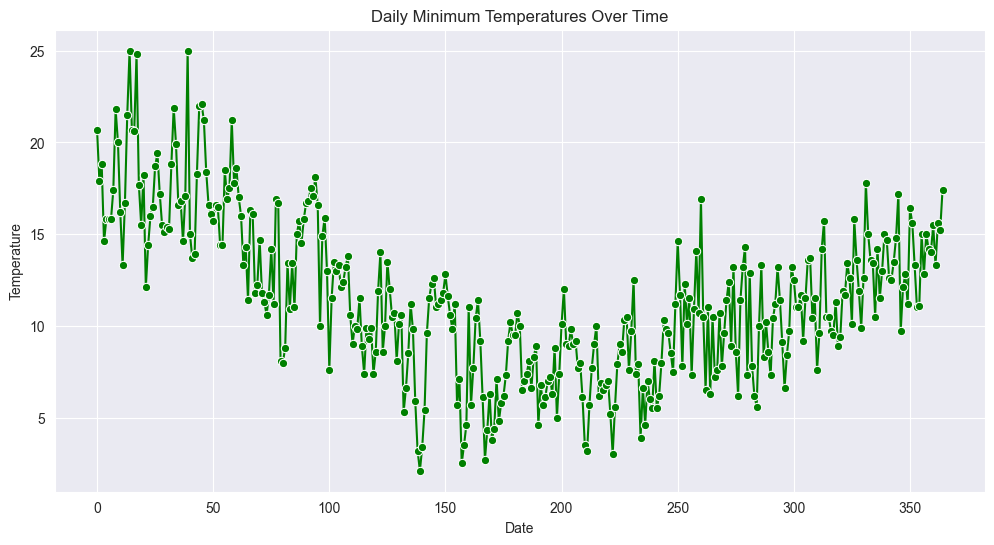

In [12]:


# Set the style to dark grid for better visibility
sns.set_style("darkgrid")

# Create the plot figure
plt.figure(figsize=(12, 6))
# Convert Date to datetime if it's not already
df['Date'] = pd.to_datetime(df['Date'])
# Filter for the first year
first_year_df = df[df['Date'].dt.year == 1981]
# Plot the time series data with green line color and markers
sns.lineplot(data=first_year_df, x=first_year_df.index, y='Daily minimum temperatures', marker='o', color='green')

# Set the title and axis labels
plt.title('Daily Minimum Temperatures Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature')

# Display the grid
plt.grid(True)

# Show the plot
plt.show()


In [13]:
# df=first_year_df

## Persistence Model Forecast

In [14]:
# Create the 'Persistence Forecast' column for the entire dataset
df['Persistence_Forecast'] = df['Daily minimum temperatures'].shift(1)  # Shift the actual values by 1 day

# Drop the first row as it will have a NaN forecast
df.dropna(subset=['Persistence_Forecast'], inplace=True)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3649 entries, 1 to 3649
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        3649 non-null   datetime64[ns]
 1   Daily minimum temperatures  3649 non-null   float64       
 2   Persistence_Forecast        3649 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 114.0 KB


## SArima Model Forcast

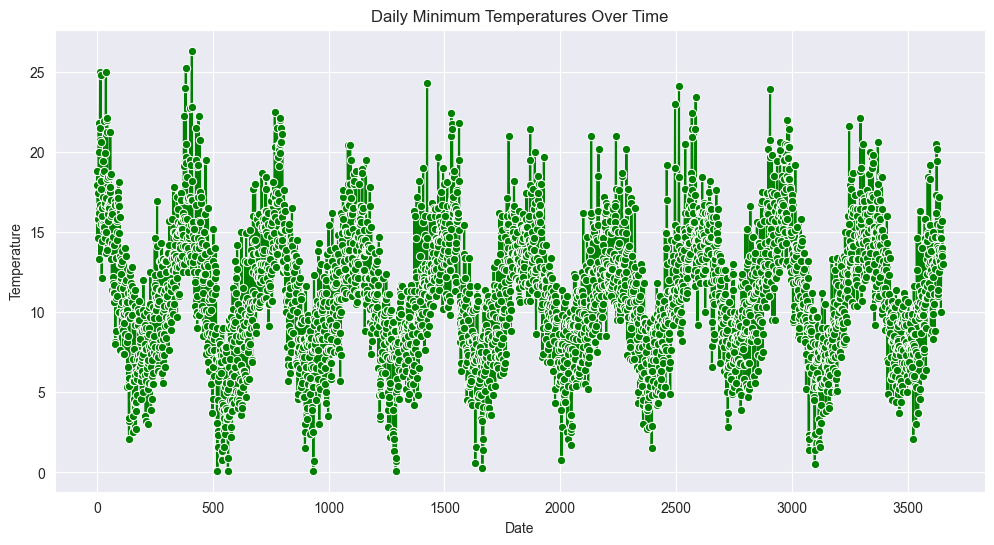

In [16]:

# Set the style to dark grid for better visibility
sns.set_style("darkgrid")

# Create the plot figure
plt.figure(figsize=(12, 6))

# Plot the time series data with green line color and markers
sns.lineplot(data=df, x=df.index, y='Daily minimum temperatures', marker='o', color='green')

# Set the title and axis labels
plt.title('Daily Minimum Temperatures Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature')

# Display the grid
plt.grid(True)

# Show the plot
plt.show()


### Stationarity Check


In [17]:
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
# Call the function and run the test

adf_test(df['Daily minimum temperatures'])

Results of Dickey-Fuller Test:
Test Statistic                   -4.337989
p-value                           0.000382
#Lags Used                       20.000000
Number of Observations Used    3628.000000
Critical Value (1%)              -3.432154
Critical Value (5%)              -2.862337
Critical Value (10%)             -2.567194
dtype: float64


In [18]:
def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','#Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

kpss_test(df['Daily minimum temperatures'])

Results of KPSS Test:
Test Statistic            0.055731
p-value                   0.100000
#Lags Used               36.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11072\2834617279.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression='c', nlags="auto")


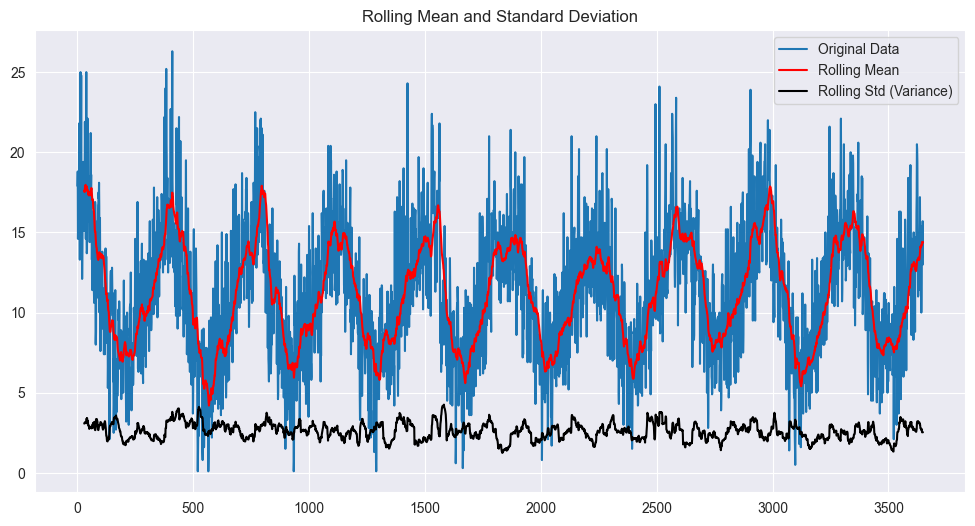

In [19]:

rolling_window = 30

# Calculate rolling statistics
rolling_mean = df['Daily minimum temperatures'].rolling(window=rolling_window).mean()
rolling_std = df['Daily minimum temperatures'].rolling(window=rolling_window).std()

# Plot original data, rolling mean and rolling std
plt.figure(figsize=(12,6))
plt.plot(df['Daily minimum temperatures'], label='Original Data')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std (Variance)')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')
plt.show()


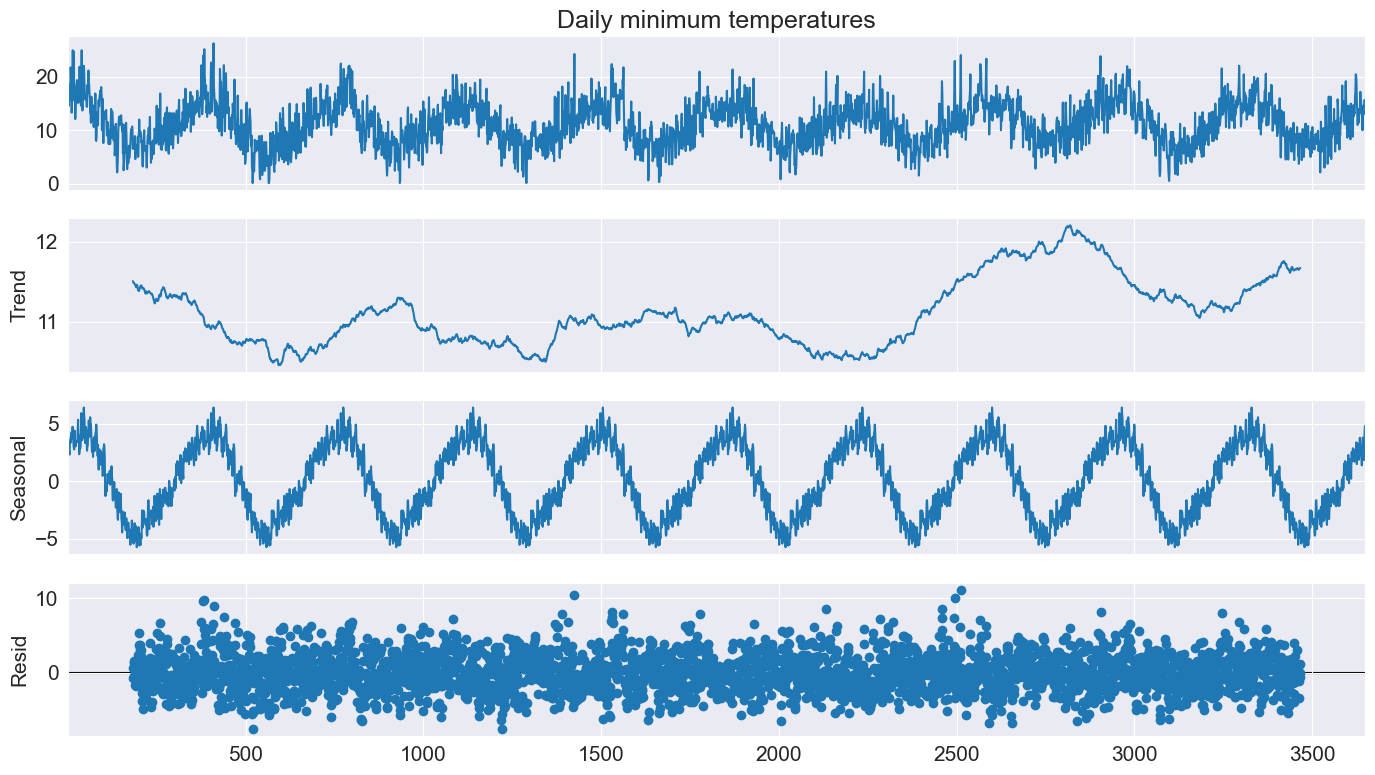

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming 'temperature' is the column you're analyzing
temperature_data = df['Daily minimum temperatures']  # Extract the temperature data

plt.rc('figure', figsize=(14, 8))
plt.rc('font', size=15)

# Perform seasonal decomposition
result = seasonal_decompose(temperature_data, model='additive', period=365)  # Adjust 'period' based on data frequency

# Plot the decomposition
fig = result.plot()
plt.show()


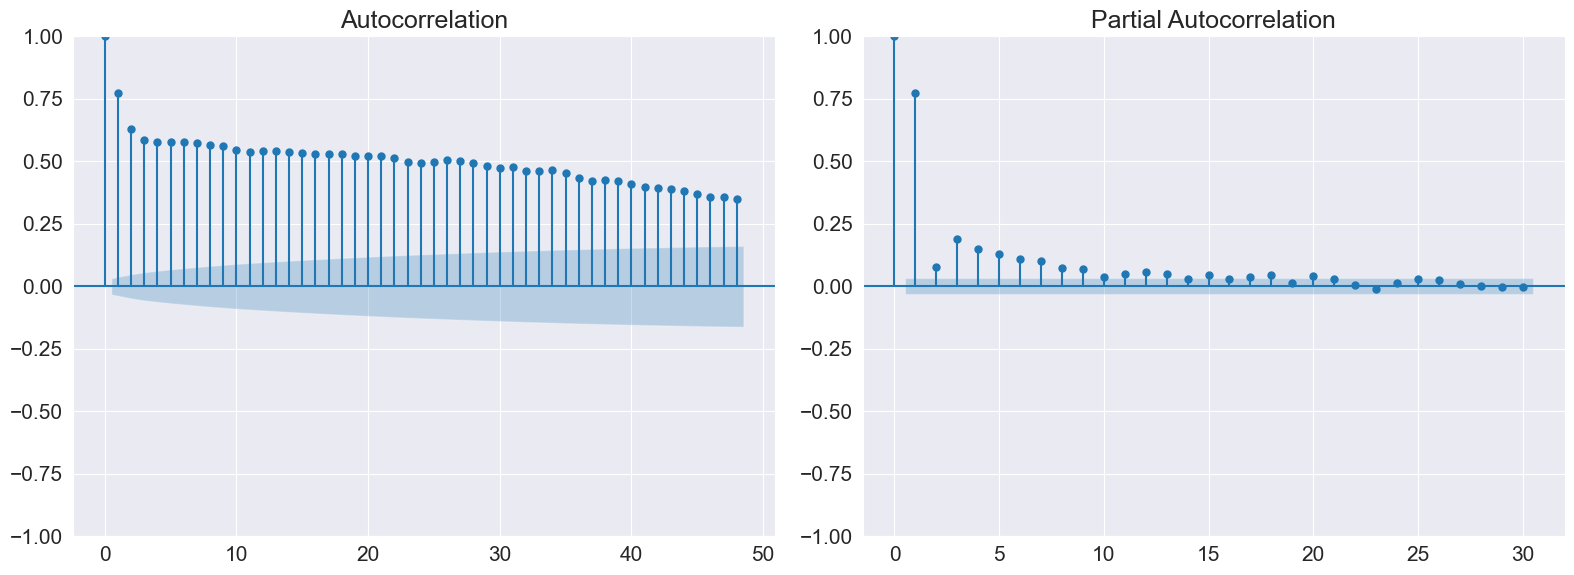

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(temperature_data, lags=48, ax=axes[0])

plot_pacf(temperature_data, lags=30, ax=axes[1])

# Display the plots
plt.tight_layout()
plt.show()


### The data is stationary and seasonal.

* The Augmented Dickey-Fuller (ADF) test gives a low p-value, indicating that the data is stationary.

* The KPSS test gives a high p-value, confirming the stationarity of the data.

* From the plot:

    * The variance remains relatively stable over time.

    * The mean stays within a certain range and, although it oscillates due to seasonality, it does not show a clear upward or downward trend.

Thus, both statistical tests and visual inspection confirm that the data is stationary with a seasonal pattern.



In [22]:
# # Split the data
# from sklearn.model_selection import TimeSeriesSplit
# X = df.drop(columns=['Daily minimum temperatures'])  # Features, could be previous time steps of temperature
# y = df['Daily minimum temperatures']  # Temperature values you're forecasting
# tscv = TimeSeriesSplit(n_splits=5)
# for train_index, test_index in tscv.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [23]:
import statsmodels.api as sm

# Fit SARIMA
model = sm.tsa.statespace.SARIMAX(
    df['Daily minimum temperatures'],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 365),
    enforce_stationarity=False,
    enforce_invertibility=False
)



c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:          Daily minimum temperatures   No. Observations:                 3649
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 365)   Log Likelihood               -7039.468
Date:                             Thu, 01 May 2025   AIC                          14088.937
Time:                                     02:27:26   BIC                          14118.828
Sample:                                          0   HQIC                         14099.704
                                            - 3649                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3645      0.033     10.886      0.000       0.299       0.430
ma.L1          0.1881      

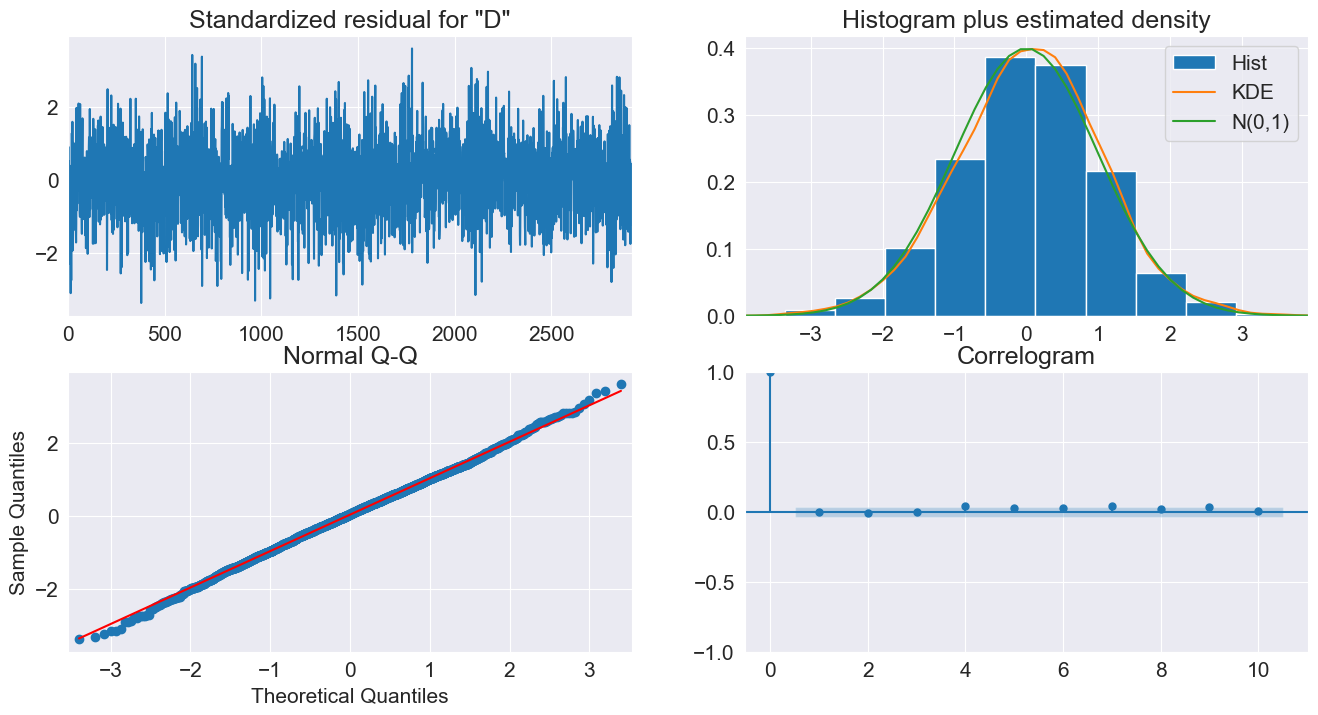

In [24]:
# %%time
results = model.fit(low_memory=True)

# Summary of the model
print(results.summary())

# Plot diagnostics
results.plot_diagnostics(figsize=(16, 8))
plt.show()


In [25]:
#  Forecast future values
forecast_steps = int(len(df) * 0.4)

forecast = results.forecast(steps=forecast_steps)

df['SARIMA_Forecast'] = np.nan


df.loc[df.index[-forecast_steps:], 'SARIMA_Forecast'] = forecast.values


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
df.isnull().sum()

Date                             0
Daily minimum temperatures       0
Persistence_Forecast             0
SARIMA_Forecast               2190
dtype: int64

In [27]:
df.dropna(subset=['SARIMA_Forecast'], inplace=True)


In [28]:
df.isnull().sum()

Date                          0
Daily minimum temperatures    0
Persistence_Forecast          0
SARIMA_Forecast               0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 2191 to 3649
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        1459 non-null   datetime64[ns]
 1   Daily minimum temperatures  1459 non-null   float64       
 2   Persistence_Forecast        1459 non-null   float64       
 3   SARIMA_Forecast             1459 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 57.0 KB


In [30]:
df

,Date,Daily minimum temperatures,Persistence_Forecast,SARIMA_Forecast
2191,1987-01-02,13.8,12.3,13.199247
2192,1987-01-03,15.3,13.8,14.653885
2193,1987-01-04,15.6,15.3,14.519200
2194,1987-01-05,16.2,15.6,14.422689
2195,1987-01-06,16.3,16.2,13.469729
...,...,...,...,...
3645,1990-12-27,14.0,14.6,14.533157
3646,1990-12-28,13.6,14.0,13.289607
3647,1990-12-29,13.5,13.6,12.947903
3648,1990-12-30,15.7,13.5,13.023202


### MAE (Mean Absolute Error)



In [31]:
Persistence_MAE=mean_absolute_error(df['Daily minimum temperatures'],df['Persistence_Forecast'])
SARIMA_MAE=mean_absolute_error(df['Daily minimum temperatures'],df['SARIMA_Forecast'])
print(f'Mean Absolute Error (Persistence_MAE): {Persistence_MAE:.4f}')
print(f'Mean Absolute Error (SARIMA_MAE): {SARIMA_MAE:.4f}')

Mean Absolute Error (Persistence_MAE): 2.0235
Mean Absolute Error (SARIMA_MAE): 2.0554


### RMSE (Root Mean Squared Error)



In [32]:
Persistence_RMSE=root_mean_squared_error(df['Daily minimum temperatures'],df['Persistence_Forecast'])
SARIMA_RMSE=root_mean_squared_error(df['Daily minimum temperatures'],df['SARIMA_Forecast'])
print(f"Root Mean Squared Error for Presistence (RMSE): {Persistence_RMSE:.4f}")
print(f"Root Mean Squared Error for SARIMA (RMSE): {SARIMA_RMSE:.4f}")


Root Mean Squared Error for Presistence (RMSE): 2.6032
Root Mean Squared Error for SARIMA (RMSE): 2.6114


### MAPE (Mean Absolute Percentage Error)

In [33]:
# Calculate the forecast errors
Presistance_Error = df['Daily minimum temperatures'] - df['Persistence_Forecast']
sarima_Error = df['Daily minimum temperatures'] - df['SARIMA_Forecast']

# Calculate the absolute errors
pre_Absolute_Error= Presistance_Error.abs()
sarima_Absolute_Error = sarima_Error.abs()

# Calculate the percentage errors
pre_Percentage_Error = (pre_Absolute_Error / df['Daily minimum temperatures']) *100
sarima_Percentage_Error = (sarima_Absolute_Error / df['Daily minimum temperatures']) *100

Persistence_MAPE=pre_Percentage_Error.mean()
SARIMA_MAPE=sarima_Percentage_Error.mean()
print(f'Mean Absolute Percentage Error for Persistence (MAPE): {Persistence_MAPE}')
print(f'Mean Absolute Percentage Error for Sarima      (MAPE): {SARIMA_MAPE}')

Mean Absolute Percentage Error for Persistence (MAPE): 21.3413851954366
Mean Absolute Percentage Error for Sarima      (MAPE): 22.63528602481505


### sMAPE (Symmetric Mean Absolute Percentage Error)

In [35]:
Persistence_sMAPE=np.mean(
    pre_Absolute_Error/((df['Daily minimum temperatures'] + df['Persistence_Forecast'])/2))*100
SARIMA_sMAPE=np.mean(
    sarima_Absolute_Error/((df['Daily minimum temperatures'] + df['SARIMA_Forecast'])/2))*100

print(f"Symmetric Mean Absolute Percentage Error for Persistence (SMAPE): {Persistence_sMAPE:.4f}")
print(f"Symmetric Mean Absolute Percentage Error for Sarima      (SMAPE): {SARIMA_sMAPE:.4f}")


Symmetric Mean Absolute Percentage Error for Persistence (SMAPE): 20.0141
Symmetric Mean Absolute Percentage Error for Sarima      (SMAPE): 19.8131


### Median Absolute Percentage Error (MDAPE)

In [36]:
Persistence_MDAPE = np.median(pre_Absolute_Error/ df['Daily minimum temperatures'])*100
SARIMA_MDAPE = np.median(sarima_Absolute_Error/ df['Daily minimum temperatures'])*100

print(f"Median Absolute Percentage Errorfor Persistence (MDAPE): {Persistence_MDAPE:.4f}")
print(f"Median Absolute Percentage Error for Sarima     (MDAPE): {SARIMA_MDAPE:.4f}")

Median Absolute Percentage Errorfor Persistence (MDAPE): 14.6154
Median Absolute Percentage Error for Sarima     (MDAPE): 14.8150


### Geometric Mean Relative Absolute Error (GMRAE)

In [37]:
Persistence_GMRAE =np.prod(pre_Absolute_Error/ df['Daily minimum temperatures']) ** (1/len(df['Daily minimum temperatures']))*100
SARIMA_GMRAE =np.prod(sarima_Absolute_Error/ df['Daily minimum temperatures']) ** (1/len(df['Daily minimum temperatures']))*100

print(f"Geometric Mean Relative Absolute Error for Persistence (GMRAE): {Persistence_GMRAE:.4f}")
print(f"Geometric Mean Relative Absolute Error for Sarima      (GMRAE): {SARIMA_GMRAE:.4f}")

Geometric Mean Relative Absolute Error for Persistence (GMRAE): 0.0000
Geometric Mean Relative Absolute Error for Sarima      (GMRAE): 0.0000


In [39]:
import pandas as pd

# Create a summary table with forecast types as columns and metrics as rows
summary_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MDAPE', 'GMRAE'],
    'Persistence': [Persistence_MAE, Persistence_RMSE, Persistence_MAPE,
                    Persistence_sMAPE, Persistence_MDAPE, Persistence_GMRAE],
    'SARIMA': [SARIMA_MAE, SARIMA_RMSE, SARIMA_MAPE,
               SARIMA_sMAPE, SARIMA_MDAPE, SARIMA_GMRAE]
})

# Set 'Metric' as the index for cleaner display
summary_table.set_index('Metric', inplace=True)

# Display the summary table
print("\nAccuracy Metrics Summary:")
print(summary_table)



Accuracy Metrics Summary:
        Persistence     SARIMA
Metric                        
MAE        2.023509   2.055386
RMSE       2.603176   2.611391
MAPE      21.341385  22.635286
sMAPE     20.014106  19.813067
MDAPE     14.615385  14.815017
GMRAE      0.000000   0.000000



###  **Brief Analysis of the Results**

#### 1. **Comparison of Magnitudes**
- **MAE (Mean Absolute Error)**:
  - Both models have very low average absolute errors; Persistence is slightly better.
  
- **RMSE (Root Mean Squared Error)**:
  - Almost identical, but RMSE being slightly higher than MAE indicates some larger errors exist.

- **MAPE (Mean Absolute Percentage Error)**:
  -  Moderate error relative to actual values. SARIMA has a slightly higher relative error.

- **sMAPE (Symmetric MAPE)**:
  - SARIMA performs slightly better when adjusted for symmetry; useful since actual values are never near zero.

- **MDAPE (Median APE)**:
  - Very close, indicates the "typical" case error is lower than the mean (MAPE), showing some outliers may exist.

- **GMRAE (Geometric Mean Relative Absolute Error)**:
  - Likely undefined or zero because the benchmark model (used for comparison) had zero or near-zero error. This makes the ratio collapse.

---

###  **Metric Behavior and Sensitivity**

- **MAE**:
  - Treats all errors equally.
  - Not sensitive to large outliers.
  - Advantage: Interpretable in the original unit (°C).
  - Disadvantage: Doesn’t emphasize large errors.

- **RMSE**:
  - Squares errors, so large errors have more weight.
  - Advantage: Penalizes large mistakes.
  - Disadvantage: Not robust to outliers.

- **MAPE**:
  - Measures error relative to actual values.
  - Advantage: Easy to interpret as a percentage.
  - Disadvantage: Sensitive to small actual values (can explode if actual ≈ 0).

- **sMAPE**:
  - Uses the average of actual and forecast as the denominator.
  - Advantage: Bounded and less sensitive to small values.
  - Disadvantage: Still has some volatility when both actual and forecast are small.

- **MDAPE**:
  - Median version of MAPE; more robust to outliers.
  - Advantage: Shows typical error.
  - Disadvantage: Ignores large errors.

- **GMRAE**:
  - Measures relative error using a geometric mean.
  - In this case: **0.0**, likely because the benchmark error was zero → division by zero issue.
  - → **Undefined or misleading here.**

---

###  **Metric Suitability**

- **Use MAE or RMSE** for stable, unit-based interpretation.
- **sMAPE or MDAPE** are better if you're worried about skew or outliers.
- **Avoid MAPE** if actual values can get close to zero.
- **Ignore GMRAE** in this case — it's **not valid** due to zero division (benchmark errors were probably too small or 0).
